In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from obspy.clients.fdsn import Client
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset

# Set global font to Helvetica
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.size'] = 15 

/Users/russell/anaconda3/envs/sitesearch/lib/python3.11/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/Users/russell/anaconda3/envs/sitesearch/lib/python3.11/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


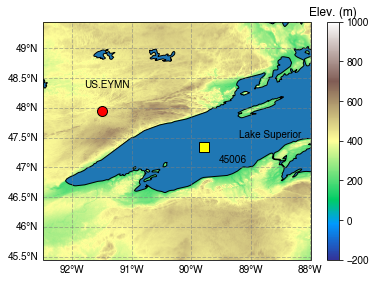

In [ ]:
network = 'US'
station = 'EYMN'

buoy = '45006'
buoy_lat = 47.335
buoy_lon = -89.793

client = Client("IRIS")
inventory = client.get_stations(network=network, station=station)

stalat = inventory[0][0].latitude
stalon = inventory[0][0].longitude

# Load Topography dataset
path2grdfile = '/Users/russell/Lamont/GMT/grids/etopo1.grd'
etopodata = Dataset(path2grdfile)
lons_e = np.linspace(etopodata.variables['x_range'][0],
                    etopodata.variables['x_range'][1],
                    etopodata.variables['dimension'][0])
lats_e = np.linspace(etopodata.variables['y_range'][0],
                    etopodata.variables['y_range'][1],
                    etopodata.variables['dimension'][1])
etopo = etopodata.variables['z'][:]
etopo = np.reshape(etopo,etopodata.variables['dimension'][::-1])

# Generate the map
# Map projection
data_proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection=data_proj)
ax.set_extent([stalon-1, stalon+3.5, stalat-2.5, stalat+1.5], crs=data_proj)
img_extent = (-180, 180, -90, 90)
pos = ax.imshow(etopo, origin='upper', extent=img_extent, transform=data_proj,
            cmap='terrain', alpha=1, zorder=-1)
cb = plt.colorbar(pos, ax=ax, shrink=0.73)
cb.ax.set_title('Elev. (m)')
cmax = etopo.max()
cmin = etopo.min()
pos.set_clim(-200,1000)
# Add contour at zero elevation
# ax.contour(lons_e, lats_e, np.flipud(etopo), levels=[0], colors='k', linewidths=1, transform=data_proj, zorder=1)
# ax.add_feature(cfeature.OCEAN,facecolor=cfeature.COLORS['water'])
# ax.add_feature(cfeature.LAKES.with_scale('10m'), facecolor=cfeature.COLORS['water'], zorder=0)
ax.add_feature(cfeature.LAKES.with_scale('10m'), facecolor=None, zorder=0,edgecolor='black')
# ax.add_feature(cfeature.RIVERS)
# ax.coastlines(resolution='10m', zorder=3)
# ax.add_feature(cfeature.BORDERS.with_scale('50m'))
# ax.add_feature(cfeature.STATES.with_scale('50m'))
ax.annotate('Lake Superior', (-89.2,47.5), xycoords='data', transform=data_proj, color='k')

# Plot station
ax.plot(
    stalon,stalat, marker='o', markersize=10,
    c='r',
    markeredgecolor='black', transform=data_proj)
ax.annotate(network+'.'+station, (stalon-0.3,stalat+0.4), xycoords='data', transform=data_proj, color='k')

# Plot buoy
ax.plot(
    buoy_lon,buoy_lat, marker='s', markersize=10,
    c='yellow',
    markeredgecolor='black', transform=data_proj)
ax.annotate(buoy, (buoy_lon+0.25,buoy_lat-0.25), xycoords='data', transform=data_proj, color='k')
# ax.set_xlim(minlongitude,maxlongitude)
# ax.set_ylim(minlatitude,maxlatitude)

gl = ax.gridlines(crs=data_proj, draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=0)
gl.xlabels_top = False
gl.ylabels_right = False

# Ensure the directory exists
output_dir = './figs'
os.makedirs(output_dir, exist_ok=True)

# Save the figure
plt.savefig(f'{output_dir}/a1_station_map_EYMN.pdf')

